
# 금융위원회 정책자료 시계열 분석 
## 분석 내용

앞선 금융규제 샌드박스 분석에서 확인한 3개 기술축이 금융위원회 정책자료에서
2024→2025→2026 동안 어떻게 확산되고 규제·통제 언어가 어떻게 변화했는지 확인한다.

분석축은 아래 3개만 사용한다.

- **생성형 AI**
- **외부 SaaS·Cloud 활용**
- **M365·Copilot**

각 축에 대해 연도별 관련 정책문서 수와 정책 맥락을 비교한다.



## 1. 2024~2026 금융위원회 정책자료 전수 수집

`2024-01-01 ~ 현재` 기간의 금융위원회 정책자료를 수집한다.


In [1]:

# 01. 환경 설정

import re
import time
from itertools import count
from urllib.parse import urljoin

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

BASE = "https://www.fsc.go.kr"
LIST_URL = "https://www.fsc.go.kr/po010101"

START_DATE = pd.Timestamp("2024-01-01")
END_DATE = min(
    pd.Timestamp.today().normalize(),
    pd.Timestamp("2026-12-31")
)

headers = {
    "User-Agent": "Mozilla/5.0"
}

print("수집 기간:", START_DATE.date(), "~", END_DATE.date())


수집 기간: 2024-01-01 ~ 2026-09-09


In [2]:
# 02. 금융위원회 정책자료 목록 수집 — 2024~2026만 서버 날짜필터로 수집

import re
import time
import pandas as pd
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin

BASE = "https://www.fsc.go.kr"
LIST_URL = "https://www.fsc.go.kr/po010101"

START_DATE = pd.Timestamp("2024-01-01")
END_DATE = pd.Timestamp("2026-12-31")

headers = {
    "User-Agent": "Mozilla/5.0"
}

session = requests.Session()
session.headers.update(headers)

rows = []
seen_doc_ids = set()

page = 1

while True:

    params = {
        "curPage": page,
        "srchBeginDt": "2024-01-01",
        "srchEndDt": "2026-12-31",
        "srchKey": "",
        "srchText": ""
    }

    r = session.get(
        LIST_URL,
        params=params,
        timeout=(5, 15)
    )

    r.raise_for_status()

    if page == 1:
        print("요청 URL:")
        print(r.url)

    soup = BeautifulSoup(
        r.text,
        "html.parser"
    )

    links = soup.select(
        "a[href*='/po010101/']"
    )

    page_rows = []

    for a in links:

        href = a.get(
            "href",
            ""
        )

        match = re.search(
            r"/po010101/(\d+)",
            href
        )

        if not match:
            continue

        doc_id = match.group(1)

        if doc_id in seen_doc_ids:
            continue

        title = a.get_text(
            " ",
            strip=True
        )

        if not title:
            continue

        # 제목 주변 DOM에서 게시일 추출
        node = a
        date = None

        for _ in range(8):

            if node is None:
                break

            text = node.get_text(
                " ",
                strip=True
            )

            date_match = re.search(
                r"20\d{2}[.\-/]\d{1,2}[.\-/]\d{1,2}",
                text
            )

            if date_match:

                date = pd.to_datetime(
                    date_match.group(),
                    errors="coerce"
                )

                break

            node = node.parent

        if pd.isna(date):
            continue

        # 최종적으로 2024~2026만 저장
        if not (
            START_DATE
            <= date
            <= END_DATE
        ):
            continue

        seen_doc_ids.add(
            doc_id
        )

        page_rows.append({
            "doc_id": doc_id,
            "title": title,
            "date": date,
            "url": urljoin(
                BASE,
                href
            )
        })

    # 현재 페이지에서 새로운 문서가 하나도 없으면 종료
    if len(page_rows) == 0:

        print(
            f"page={page} | "
            "새로운 2024~2026 문서 없음 → 종료"
        )

        break

    rows.extend(
        page_rows
    )

    print(
        f"page={page} | "
        f"new={len(page_rows)} | "
        f"누적={len(rows):,} | "
        f"날짜="
        f"{min(x['date'] for x in page_rows).date()} "
        f"~ "
        f"{max(x['date'] for x in page_rows).date()}"
    )

    page += 1

    # 서버 부담 방지용 최소 대기
    time.sleep(0.05)


df_list = (
    pd.DataFrame(rows)
    .drop_duplicates(
        subset="doc_id"
    )
    .sort_values(
        "date"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n최종 목록:",
    len(df_list)
)

print(
    "최소 날짜:",
    df_list["date"].min()
)

print(
    "최대 날짜:",
    df_list["date"].max()
)


display(
    df_list
    .groupby(
        df_list["date"].dt.year
    )
    .size()
    .rename("문서수")
    .to_frame()
)

요청 URL:
https://www.fsc.go.kr/po010101?curPage=1&srchBeginDt=2024-01-01&srchEndDt=2026-12-31&srchKey=&srchText=
page=1 | new=10 | 누적=10 | 날짜=2026-09-02 ~ 2026-09-09
page=2 | new=10 | 누적=20 | 날짜=2026-08-28 ~ 2026-09-02
page=3 | new=10 | 누적=30 | 날짜=2026-08-20 ~ 2026-08-28
page=4 | new=10 | 누적=40 | 날짜=2026-08-12 ~ 2026-08-20
page=5 | new=10 | 누적=50 | 날짜=2026-08-03 ~ 2026-08-12
page=6 | new=10 | 누적=60 | 날짜=2026-07-30 ~ 2026-07-31
page=7 | new=10 | 누적=70 | 날짜=2026-07-22 ~ 2026-07-30
page=8 | new=10 | 누적=80 | 날짜=2026-07-15 ~ 2026-07-22
page=9 | new=10 | 누적=90 | 날짜=2026-07-14 ~ 2026-07-15
page=10 | new=10 | 누적=100 | 날짜=2026-07-08 ~ 2026-07-14
page=11 | new=10 | 누적=110 | 날짜=2026-07-06 ~ 2026-07-07
page=12 | new=10 | 누적=120 | 날짜=2026-07-01 ~ 2026-07-03
page=13 | new=10 | 누적=130 | 날짜=2026-06-29 ~ 2026-07-01
page=14 | new=10 | 누적=140 | 날짜=2026-06-25 ~ 2026-06-29
page=15 | new=10 | 누적=150 | 날짜=2026-06-22 ~ 2026-06-25
page=16 | new=10 | 누적=160 | 날짜=2026-06-17 ~ 2026-06-22
page=17 | new=10 | 누적=170 

,문서수
date,
2024,645
2025,537
2026,473


In [3]:
# 03. 2024~2026 문서 본문만 병렬 수집

from concurrent.futures import (
    ThreadPoolExecutor,
    as_completed
)


def fetch_content(row):

    try:

        r = requests.get(
            row["url"],
            headers=headers,
            timeout=(5, 10)
        )

        r.raise_for_status()

        soup = BeautifulSoup(
            r.text,
            "html.parser"
        )

        content = ""

        for selector in [
            ".view_cont",
            ".view-content",
            ".board_view",
            ".board-view",
            ".bbs_view",
            ".content",
            ".cont"
        ]:

            node = soup.select_one(
                selector
            )

            if node:

                candidate = node.get_text(
                    " ",
                    strip=True
                )

                if (
                    len(candidate)
                    > len(content)
                ):
                    content = candidate

        return {
            "doc_id": row["doc_id"],
            "content": content
        }

    except Exception as e:

        return {
            "doc_id": row["doc_id"],
            "content": "",
            "error": str(e)
        }


print(
    "본문 수집 대상:",
    len(df_list)
)

details = []

with ThreadPoolExecutor(
    max_workers=4
) as executor:

    futures = [
        executor.submit(
            fetch_content,
            row
        )
        for _, row
        in df_list.iterrows()
    ]

    for i, future in enumerate(
        as_completed(futures),
        start=1
    ):

        details.append(
            future.result()
        )

        if (
            i % 50 == 0
            or i == len(futures)
        ):
            print(
                f"{i:,} / "
                f"{len(futures):,}"
            )


df_detail = pd.DataFrame(
    details
)


df_fsc = df_list.merge(
    df_detail[
        [
            "doc_id",
            "content"
        ]
    ],
    on="doc_id",
    how="left"
)


df_fsc["year"] = (
    df_fsc["date"]
    .dt.year
)

df_fsc["month"] = (
    df_fsc["date"]
    .dt.to_period("M")
    .astype(str)
)


df_fsc["analysis_text"] = (
    df_fsc["title"]
    .fillna("")
    + " "
    + df_fsc["content"]
    .fillna("")
).str.strip()


print(
    "\n최종 분석대상:",
    len(df_fsc)
)

display(
    df_fsc
    .groupby("year")
    .size()
    .rename("문서수")
    .to_frame()
)

본문 수집 대상: 1655
50 / 1,655
100 / 1,655
150 / 1,655
200 / 1,655
250 / 1,655
300 / 1,655
350 / 1,655
400 / 1,655
450 / 1,655
500 / 1,655
550 / 1,655
600 / 1,655
650 / 1,655
700 / 1,655
750 / 1,655
800 / 1,655
850 / 1,655
900 / 1,655
950 / 1,655
1,000 / 1,655
1,050 / 1,655
1,100 / 1,655
1,150 / 1,655
1,200 / 1,655
1,250 / 1,655
1,300 / 1,655
1,350 / 1,655
1,400 / 1,655
1,450 / 1,655
1,500 / 1,655
1,550 / 1,655
1,600 / 1,655
1,650 / 1,655
1,655 / 1,655

최종 분석대상: 1655


,문서수
year,
2024,645
2025,537
2026,473



## 2. 3개 기술축 분류

샌드박스 분석과 동일하게 아래 3개 축만 추적한다.

- 생성형 AI
- 외부 SaaS·Cloud 활용
- M365·Copilot

하나의 정책문서가 여러 축에 동시에 해당할 수 있으므로 Multi-label 방식으로 분류한다.


In [4]:

# 04. 3개 기술축 Multi-label 분류

axis_patterns = {

    "생성형 AI": (
        r"생성형\s*AI|생성형AI|"
        r"\bLLM\b|대규모\s*언어모델|"
        r"생성형\s*인공지능"
    ),

    "외부 SaaS·Cloud 활용": (
        r"\bSaaS\b|서비스형\s*소프트웨어|"
        r"클라우드.*내부망|내부망.*클라우드|"
        r"SaaS.*내부망|내부망.*SaaS|"
        r"망분리.*SaaS|SaaS.*망분리"
    ),

    "M365·Copilot": (
        r"\bM365\b|Microsoft\s*365|"
        r"Office\s*365|"
        r"Copilot|코파일럿"
    )
}

for label, pattern in axis_patterns.items():
    df_fsc[label] = (
        df_fsc["analysis_text"]
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
        .astype(int)
    )

axis_cols = list(axis_patterns.keys())

print("=== 3개 기술축 전체 출현 ===")
display(
    df_fsc[axis_cols]
    .sum()
    .sort_values(ascending=False)
    .to_frame("문서수")
)


=== 3개 기술축 전체 출현 ===


,문서수
생성형 AI,49
SaaS 내부망,30
M365·Copilot,7



## 3. 2024→2025→2026 기술축 변화

각 기술축이 금융위원회 정책자료에서 언제 등장하고 얼마나 확대되는지 연도별 건수와 비율로 확인한다.


In [5]:

# 05. 연도별 3개 기술축 변화

years = [2024, 2025, 2026]

axis_year = (
    df_fsc
    .groupby("year")[axis_cols]
    .sum()
    .reindex(years, fill_value=0)
)

year_total = (
    df_fsc
    .groupby("year")
    .size()
    .reindex(years, fill_value=0)
)

axis_ratio = (
    axis_year
    .div(
        year_total.replace(0, np.nan),
        axis=0
    )
    .mul(100)
    .round(2)
)

print("=== 연도별 문서 수 ===")
display(axis_year)

print("=== 연도별 비율 (%) ===")
display(axis_ratio)


=== 연도별 문서 수 ===


,생성형 AI,SaaS 내부망,M365·Copilot
year,,,
2024,20,18,4
2025,13,5,2
2026,16,7,1


=== 연도별 비율 (%) ===


,생성형 AI,SaaS 내부망,M365·Copilot
year,,,
2024,3.10,2.79,0.62
2025,2.42,0.93,0.37
2026,3.38,1.48,0.21


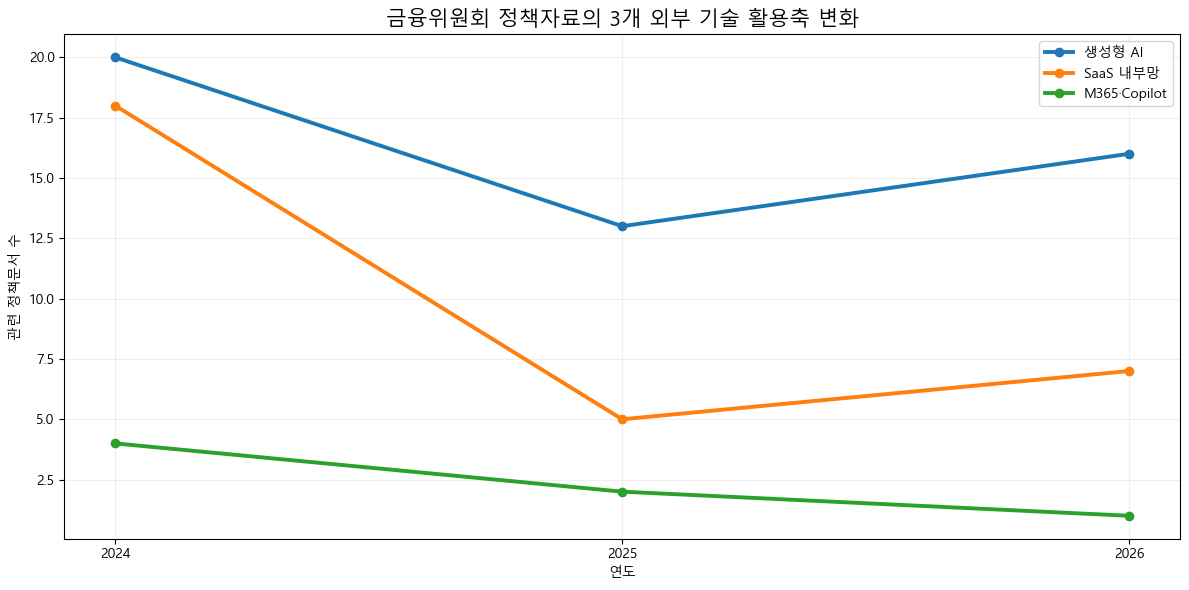

In [6]:

# 06. 2024~2026 3개 기술축 시계열 시각화

import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(12, 6))

for col in axis_cols:
    plt.plot(
        axis_year.index,
        axis_year[col],
        marker="o",
        linewidth=2.8,
        label=col
    )

plt.title(
    "금융위원회 정책자료의 3개 외부 기술 활용축 변화",
    fontsize=15
)
plt.xlabel("연도")
plt.ylabel("관련 정책문서 수")
plt.xticks(years)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()



## 4. 규제 단계 변화

3개 기술축 각각에서 정책 언어가 아래 단계로 어떻게 이동하는지 본다.

- 실증·특례
- 도입·활용
- 보안·통제
- 규제·제도개선
- 상시화·규정화


In [7]:

# 07. 정책 단계 Multi-label 분류

stage_patterns = {

    "실증·특례": (
        r"샌드박스|혁신금융서비스|규제\s*특례|"
        r"실증|시범|특례\s*지정"
    ),

    "도입·활용": (
        r"도입|활용|이용|적용|업무\s*활용|"
        r"서비스\s*활용|금융회사.*활용"
    ),

    "보안·통제": (
        r"보안|정보보호|망분리|내부망|외부망|"
        r"접근통제|보호조치|보안대책|"
        r"위험관리|리스크\s*관리|내부통제"
    ),

    "규제·제도개선": (
        r"규제\s*개선|규제개선|규제\s*완화|규제완화|"
        r"제도\s*개선|제도개선|규정\s*개정|"
        r"감독규정.*개정|가이드라인"
    ),

    "상시화·규정화": (
        r"제도화|상시화|상시\s*허용|정식\s*허용|"
        r"규정화|정규\s*제도|상시\s*제도"
    )
}

stage_cols = list(stage_patterns.keys())

for label, pattern in stage_patterns.items():
    df_fsc[label] = (
        df_fsc["analysis_text"]
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False
        )
        .astype(int)
    )


In [8]:

# 08. 기술축별 연도별 정책 단계 비율

axis_stage_results = {}

for axis in axis_cols:

    temp = (
        df_fsc.loc[
            df_fsc[axis] == 1
        ]
        .copy()
    )

    counts = (
        temp
        .groupby("year")[stage_cols]
        .sum()
        .reindex(years, fill_value=0)
    )

    totals = (
        temp
        .groupby("year")
        .size()
        .reindex(years, fill_value=0)
    )

    ratios = (
        counts
        .div(
            totals.replace(0, np.nan),
            axis=0
        )
        .mul(100)
        .round(1)
    )

    axis_stage_results[axis] = {
        "counts": counts,
        "ratios": ratios,
        "totals": totals
    }

    print("\n" + "=" * 70)
    print(axis)
    print("=" * 70)

    print("[문서 수]")
    display(counts)

    print("[관련 문서 내 정책 단계 비율 %]")
    display(ratios)



생성형 AI
[문서 수]


,실증·특례,도입·활용,보안·통제,규제·제도개선,상시화·규정화
year,,,,,
2024,8,20,18,11,3
2025,9,13,9,8,1
2026,12,16,11,6,2


[관련 문서 내 정책 단계 비율 %]


,실증·특례,도입·활용,보안·통제,규제·제도개선,상시화·규정화
year,,,,,
2024,40.0,100.0,90.0,55.0,15.0
2025,69.2,100.0,69.2,61.5,7.7
2026,75.0,100.0,68.8,37.5,12.5



SaaS 내부망
[문서 수]


...

,실증·특례,도입·활용,보안·통제,규제·제도개선,상시화·규정화
year,,,,,
2024,100.0,100.0,83.3,66.7,11.1
2025,100.0,100.0,100.0,60.0,20.0
2026,71.4,100.0,71.4,71.4,42.9



M365·Copilot
[문서 수]


,실증·특례,도입·활용,보안·통제,규제·제도개선,상시화·규정화
year,,,,,
2024,4,4,3,3,1
2025,2,2,2,0,0
2026,1,1,0,0,0


[관련 문서 내 정책 단계 비율 %]


,실증·특례,도입·활용,보안·통제,규제·제도개선,상시화·규정화
year,,,,,
2024,100.0,100.0,75.0,75.0,25.0
2025,100.0,100.0,100.0,0.0,0.0
2026,100.0,100.0,0.0,0.0,0.0



## 5. 2024→2025→2026 정책 워딩 변화

앞의 문서 수와 정책 단계 비율은 **정책 관심이 얼마나 있었는지**를 확인하기 위한 보조지표다.

여기서부터는 각 기술축 관련 문서에서 실제로 어떤 표현이 상대적으로 강해졌는지를 본다.

- 같은 기술축 안에서 2024·2025·2026 문서를 함께 비교
- 기술명 자체(`AI`, `SaaS`, `M365`, `Copilot`)는 제외
- 각 연도에서 다른 연도보다 상대적으로 강한 1~2gram을 추출
- 단순 빈도가 아니라 `해당 연도 평균 TF-IDF - 다른 연도 평균 TF-IDF`로 차별 워딩을 계산

따라서 이 시각화의 목적은 **문서 건수 증가·감소 자체가 아니라, 샌드박스에서 확인된 외부 활용 기술을 금융위가 어떤 언어로 다루기 시작했는지**를 설명하는 것이다.


In [18]:
# 09. 정책 워딩 변화 분석
# TF-IDF 제거
# 기술 언급 주변 문맥에서 정책어 사전 출현 비율 계산

import re
import numpy as np
import pandas as pd

from collections import Counter


analysis_axes = [
    "생성형 AI",
    "외부 SaaS·Cloud 활용"
]

years = [
    2024,
    2025,
    2026
]


axis_context_patterns = {

    "생성형 AI": (
        r"생성형\s*AI|생성형AI|"
        r"\bAI\b|인공지능|"
        r"\bLLM\b|대규모\s*언어모델"
    ),

    "외부 SaaS·Cloud 활용": (
        r"\bSaaS\b|"
        r"서비스형\s*소프트웨어|"
        r"내부망|망분리|업무망|"
        r"클라우드"
    ),

    "M365·Copilot": (
        r"\bM365\b|"
        r"Microsoft\s*365|"
        r"Office\s*365|"
        r"Copilot|코파일럿"
    )
}


policy_wording_patterns = {

    "실증·특례": (
        r"샌드박스|"
        r"혁신금융서비스|"
        r"규제\s*특례|"
        r"특례\s*지정|"
        r"실증|"
        r"시범|"
        r"신규\s*지정|"
        r"지정\s*의결"
    ),

    "허용·활용": (
        r"활용|"
        r"이용|"
        r"도입|"
        r"업무\s*활용|"
        r"업무망|"
        r"내부망\s*이용|"
        r"적용|"
        r"사용"
    ),

    "보안·통제": (
        r"망분리|"
        r"보안|"
        r"정보보호|"
        r"접근통제|"
        r"내부통제|"
        r"보호조치|"
        r"위험관리|"
        r"리스크\s*관리"
    ),

    "규제개선": (
        r"규제\s*개선|"
        r"규제개선|"
        r"규제\s*완화|"
        r"규제완화|"
        r"완화|"
        r"제도\s*개선|"
        r"규정\s*개정|"
        r"절차\s*간소화|"
        r"예외"
    ),

    "상시화·제도화": (
        r"상시\s*허용|"
        r"상시화|"
        r"제도화|"
        r"정식\s*허용|"
        r"규정화|"
        r"정규\s*제도"
    )
}

In [19]:
# 10. 기술 키워드 주변 문맥 추출

def extract_context_windows(
    text,
    pattern,
    window=150
):

    if pd.isna(text):
        return ""

    text = str(text)

    contexts = []

    for match in re.finditer(
        pattern,
        text,
        flags=re.I
    ):

        start = max(
            0,
            match.start() - window
        )

        end = min(
            len(text),
            match.end() + window
        )

        contexts.append(
            text[start:end]
        )

    return " ".join(
        contexts
    )

In [20]:
# 11. 기술축 × 연도 × 정책 언어 집계

policy_rows = []

for axis in analysis_axes:

    axis_pattern = (
        axis_context_patterns[axis]
    )

    temp = (
        df_fsc.loc[
            df_fsc[axis] == 1,
            [
                "year",
                "analysis_text"
            ]
        ]
        .copy()
    )

    temp["axis_context"] = (
        temp["analysis_text"]
        .apply(
            lambda x:
            extract_context_windows(
                x,
                axis_pattern
            )
        )
    )

    temp = (
        temp.loc[
            temp["axis_context"]
            .str.len() > 0
        ]
        .copy()
    )

    for year in years:

        year_df = (
            temp.loc[
                temp["year"] == year
            ]
            .copy()
        )

        n_docs = len(
            year_df
        )

        if n_docs == 0:
            continue

        for category, pattern in (
            policy_wording_patterns.items()
        ):

            hit_count = 0
            matched_terms = []

            for text in (
                year_df["axis_context"]
            ):

                matches = re.findall(
                    pattern,
                    str(text),
                    flags=re.I
                )

                if matches:

                    hit_count += 1

                    matched_terms.extend(
                        [
                            str(x).strip()
                            for x in matches
                        ]
                    )

            ratio = (
                hit_count
                / n_docs
                * 100
            )

            term_counter = Counter(
                matched_terms
            )

            top_terms = [
                term
                for term, _
                in term_counter.most_common(4)
            ]

            policy_rows.append({

                "axis": axis,

                "year": year,

                "n_docs": n_docs,

                "policy_language":
                    category,

                "hit_docs":
                    hit_count,

                "ratio":
                    round(ratio, 1),

                "actual_wording":
                    " · ".join(
                        top_terms
                    )
            })


policy_wording_shift = (
    pd.DataFrame(
        policy_rows
    )
)

In [21]:
# 12. 정책 워딩 분석 결과 확인

print(
    "=== 기술축별 정책 워딩 변화 ==="
)

display(
    policy_wording_shift[
        [
            "axis",
            "year",
            "n_docs",
            "policy_language",
            "hit_docs",
            "ratio",
            "actual_wording"
        ]
    ]
    .sort_values(
        [
            "axis",
            "year",
            "ratio"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

=== 기술축별 정책 워딩 변화 ===


,axis,year,n_docs,policy_language,hit_docs,ratio,actual_wording
0,SaaS 내부망,2024,18,실증·특례,17,94.4,혁신금융서비스 · 신규 지정 · 샌드박스 · 규제 특례
1,SaaS 내부망,2024,18,허용·활용,17,94.4,활용 · 이용 · 내부망 이용 · 도입
2,SaaS 내부망,2024,18,보안·통제,11,61.1,망분리 · 보안 · 리스크 관리
3,SaaS 내부망,2024,18,규제개선,11,61.1,규제 개선 · 예외 · 규제개선 · 완화
4,SaaS 내부망,2024,18,상시화·제도화,0,0.0,
5,SaaS 내부망,2025,5,허용·활용,5,100.0,활용 · 내부망 이용 · 이용 · 사용
6,SaaS 내부망,2025,5,실증·특례,4,80.0,혁신금융서비스 · 신규 지정 · 샌드박스 · 규제 특례
7,SaaS 내부망,2025,5,보안·통제,4,80.0,망분리 · 보안
8,SaaS 내부망,2025,5,규제개선,3,60.0,규제개선 · 규제 개선 · 제도 개선
9,SaaS 내부망,2025,5,상시화·제도화,0,0.0,


In [22]:
# 13. 발표용 시각화 환경 설정

import matplotlib.pyplot as plt

from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch
)


plt.rcParams[
    "font.family"
] = "Malgun Gothic"

plt.rcParams[
    "axes.unicode_minus"
] = False


NAVY_900 = "#0B1F3A"
NAVY_700 = "#173F73"
NAVY_500 = "#315F96"
NAVY_200 = "#C6D5E7"
NAVY_100 = "#EAF0F7"

TEXT = "#1E293B"
MUTED = "#64748B"
WHITE = "#FFFFFF"

In [23]:
# 14. 연도별 상위 정책 언어 함수

def get_policy_lines(
    axis,
    year,
    top_n=3
):

    temp = (
        policy_wording_shift.loc[
            (
                policy_wording_shift[
                    "axis"
                ] == axis
            )
            &
            (
                policy_wording_shift[
                    "year"
                ] == year
            )
        ]
        .sort_values(
            "ratio",
            ascending=False
        )
        .head(top_n)
    )

    if temp.empty:

        return [
            "관련 표현 없음"
        ], 0

    n_docs = int(
        temp[
            "n_docs"
        ].iloc[0]
    )

    lines = []

    for _, row in (
        temp.iterrows()
    ):

        lines.append(
            f"{row['policy_language']}  "
            f"{row['ratio']:.1f}%"
        )

    return (
        lines,
        n_docs
    )

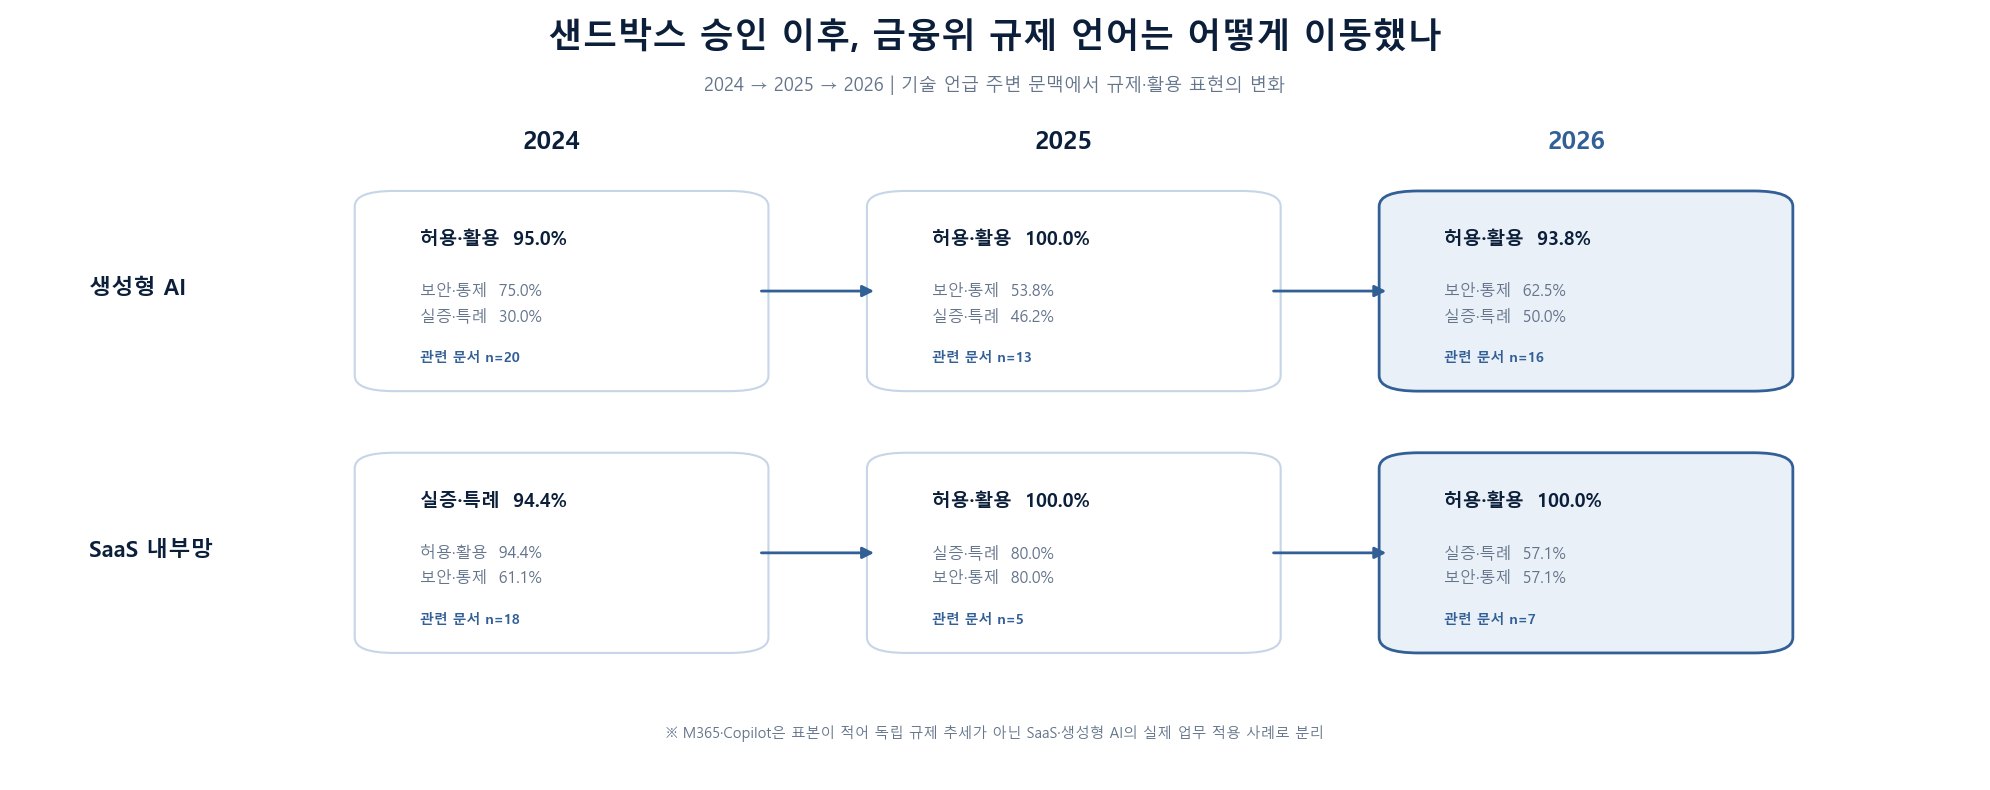

In [24]:
# 15. 발표용 시각화

fig, ax = plt.subplots(
    figsize=(20, 8)
)

ax.axis("off")


ax.text(
    0.5,
    0.95,
    "샌드박스 승인 이후, 금융위 규제 언어는 어떻게 이동했나",
    ha="center",
    fontsize=25,
    fontweight="bold",
    color=NAVY_900,
    transform=ax.transAxes
)


ax.text(
    0.5,
    0.895,
    "2024 → 2025 → 2026 | 기술 언급 주변 문맥에서 규제·활용 표현의 변화",
    ha="center",
    fontsize=13,
    color=MUTED,
    transform=ax.transAxes
)


x_positions = {
    2024: 0.19,
    2025: 0.45,
    2026: 0.71
}

y_positions = {
    "생성형 AI": 0.52,
    "외부 SaaS·Cloud 활용": 0.18
}


for year, x in (
    x_positions.items()
):

    ax.text(
        x + 0.085,
        0.82,
        str(year),
        ha="center",
        fontsize=18,
        fontweight="bold",
        color=(
            NAVY_500
            if year == 2026
            else NAVY_900
        ),
        transform=ax.transAxes
    )


def draw_box(
    x,
    y,
    axis,
    year
):

    lines, n_docs = (
        get_policy_lines(
            axis,
            year
        )
    )

    w = 0.18
    h = 0.23

    highlight = (
        year == 2026
    )

    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=(
            "round,pad=0.015,"
            "rounding_size=0.02"
        ),
        linewidth=(
            2
            if highlight
            else 1.5
        ),
        edgecolor=(
            NAVY_500
            if highlight
            else NAVY_200
        ),
        facecolor=(
            NAVY_100
            if highlight
            else WHITE
        ),
        transform=ax.transAxes
    )

    ax.add_patch(
        patch
    )

    ax.text(
        x + 0.018,
        y + h - 0.055,
        lines[0],
        fontsize=13.5,
        fontweight="bold",
        color=NAVY_900,
        transform=ax.transAxes
    )

    if len(lines) > 1:

        ax.text(
            x + 0.018,
            y + h - 0.105,
            "\n".join(
                lines[1:]
            ),
            fontsize=11.5,
            color=MUTED,
            va="top",
            linespacing=1.6,
            transform=ax.transAxes
        )

    ax.text(
        x + 0.018,
        y + 0.023,
        f"관련 문서 n={n_docs}",
        fontsize=10,
        fontweight="bold",
        color=NAVY_500,
        transform=ax.transAxes
    )


def draw_arrow(
    x1,
    x2,
    y
):

    arrow = FancyArrowPatch(
        (x1, y),
        (x2, y),
        arrowstyle="-|>",
        mutation_scale=17,
        linewidth=2,
        color=NAVY_500,
        transform=ax.transAxes
    )

    ax.add_patch(
        arrow
    )


for axis, y in (
    y_positions.items()
):

    ax.text(
        0.04,
        y + 0.11,
        axis,
        fontsize=16,
        fontweight="bold",
        color=NAVY_900,
        transform=ax.transAxes
    )

    for year, x in (
        x_positions.items()
    ):

        draw_box(
            x,
            y,
            axis,
            year
        )

    draw_arrow(
        0.38,
        0.44,
        y + 0.115
    )

    draw_arrow(
        0.64,
        0.70,
        y + 0.115
    )


ax.text(
    0.5,
    0.055,
    "※ M365·Copilot은 표본이 적어 독립 규제 추세가 아닌 SaaS·생성형 AI의 실제 업무 적용 사례로 분리",
    ha="center",
    fontsize=10.5,
    color=MUTED,
    transform=ax.transAxes
)


plt.tight_layout()
plt.show()

In [25]:
# 16. M365·Copilot 별도 Evidence 확인

m365_counts = (
    df_fsc.loc[
        df_fsc[
            "M365·Copilot"
        ] == 1
    ]
    .groupby(
        "year"
    )
    .size()
    .reindex(
        years,
        fill_value=0
    )
)


print(
    "=== M365·Copilot 관련 문서 수 ==="
)


display(
    m365_counts
    .rename(
        "문서수"
    )
    .to_frame()
)


print(
    "M365·Copilot은 문서 수가 적으므로 "
    "연도별 규제 추세가 아니라 "
    "SaaS·생성형 AI의 실제 업무 적용 Evidence로 해석한다."
)

=== M365·Copilot 관련 문서 수 ===


,문서수
year,
2024,4
2025,2
2026,1


M365·Copilot은 문서 수가 적으므로 연도별 규제 추세가 아니라 SaaS·생성형 AI의 실제 업무 적용 Evidence로 해석한다.



## 6. 설명 

이 분석의 결론은 **“관련 문서가 늘었다/줄었다”**가 아니다.

앞선 샌드박스 분석에서 생성형 AI·SaaS·M365/Copilot이 실제 규제특례 대상으로 등장했다.  
따라서 여기서는 그 이후 금융위원회의 정책 언어가 어떻게 변했는지를 본다.

**1. 생성형 AI**

금융권에서 생성형 AI 활용 자체는 계속 나타난다.  
동시에 실증·특례와 보안·통제 언어도 함께 남아 있다면, 이는 AI가 단순 허용 단계가 끝난 것이 아니라 **활용 범위를 넓히면서 검증과 통제를 병행하는 단계**로 해석한다.

**2. 외부 SaaS·Cloud 활용**

SaaS는 가장 중요한 규제 전이 축이다.  
초기의 `특례·망분리·보안` 중심 언어가 이후 `업무 활용·규제개선·상시화` 쪽으로 이동한다면, **예외적으로 허용하던 외부 SaaS를 규정 안에서 사용할 수 있도록 제도화하는 방향**으로 읽는다.

**3. M365·Copilot**

M365·Copilot은 독립적인 규제 흐름을 대표한다고 보지 않는다.  
문서 수가 적기 때문에 **외부 SaaS·Cloud 활용과 생성형 AI가 실제 임직원 업무도구까지 들어온 구체 사례**로 사용한다.
